# 1.2 — Movimiento browniano

## Motivación

El movimiento browniano estándar (BM) es el bloque de construcción de todo el cálculo estocástico que sigue: la integral de Itô (01.3) se define como límite de sumas respecto a incrementos de BM, toda SDE (01.4) se escribe como "deriva + difusión $\times\, dW_t$", y el modelo de Black-Scholes es la exponencial de un BM con deriva. En 01.1 vimos que la caminata aleatoria simple (SRW), reescalada, converge a un proceso continuo — este notebook construye y caracteriza ese proceso límite: el BM.

Cubrimos dos construcciones —el límite de escala de una SRW (invarianza de Donsker, que ya anticipamos en 01.1) y la construcción explícita por interpolación (Lévy)— y las tres propiedades que hacen del BM un objeto tan peculiar y tan útil para modelar precios: es **continuo** pero **no diferenciable en ningún punto**, es **autosimilar** bajo el reescalamiento $t\mapsto ct$, y tiene **variación cuadrática determinista** $[W]_t=t$ mientras su variación total es infinita. Esta última propiedad es la que obliga a inventar el cálculo de Itô: las reglas del cálculo clásico (que asumen variación acotada) simplemente no aplican. Cerramos con el **puente browniano**, que aparecerá en 03.4 (lookback/barrera) y en técnicas de reducción de varianza (04.2).

**Referencias:** Shreve, *Stochastic Calculus for Finance II*, cap. 3; Karatzas & Shreve, *Brownian Motion and Stochastic Calculus*, cap. 2.

## 1. Definición y construcción

### 1.1 Definición

**Definición (movimiento browniano estándar).** Un proceso estocástico $(W_t)_{t \geq 0}$ es un **movimiento browniano estándar** (o proceso de Wiener) si:

1. $W_0 = 0$ casi seguramente.
2. **Incrementos independientes:** para cualesquiera $0 \leq t_0 < t_1 < \dots < t_n$, las variables $W_{t_1}-W_{t_0},\, W_{t_2}-W_{t_1},\,\dots,\,W_{t_n}-W_{t_{n-1}}$ son independientes.
3. **Incrementos gaussianos estacionarios:** para $0 \leq s < t$,
$$
W_t - W_s \sim \mathcal{N}(0,\, t-s).
$$
4. **Continuidad de trayectorias:** $t \mapsto W_t(\omega)$ es continua para casi todo $\omega$.

De (1)-(3) se sigue que $W_t \sim \mathcal{N}(0,t)$ y que, para $s\leq t$, $\text{Cov}(W_s,W_t) = \mathbb{E}[W_s W_t] = \mathbb{E}[W_s(W_s + (W_t-W_s))] = \mathbb{E}[W_s^2] = s = \min(s,t)$ (usando independencia de $W_s$ y $W_t-W_s$). Como $(W_{t_1},\dots,W_{t_n})$ es una transformación lineal de incrementos gaussianos independientes, es un vector gaussiano: $W$ es un **proceso gaussiano** con media $0$ y función de covarianza $\min(s,t)$. Esta caracterización (gaussiano, media $0$, covarianza $\min(s,t)$, trayectorias continuas) es equivalente a la definición anterior y es la que se usa para verificar que una construcción dada "es" BM.

### 1.2 Construcción como límite de escala de una SRW (Donsker)

Sea $(X_i)_{i\geq1}$ i.i.d. con $\mathbb{E}[X_i]=0$, $\text{Var}(X_i)=1$ (p.ej. $X_i=\pm1$ equiprobables, la SRW de 01.1) y $S_n=\sum_{i=1}^n X_i$. Definimos el proceso reescalado en $[0,1]$
$$
W^{(n)}_t = \frac{1}{\sqrt{n}}\, S_{\lfloor nt \rfloor}, \qquad t \in [0,1]
$$
(con interpolación lineal entre los puntos $\lfloor nt\rfloor/n$ para obtener trayectorias continuas). Para $t$ fijo, el CLT (00.1) da $W_t^{(n)} \xrightarrow{d} \mathcal{N}(0,t)$; y para incrementos disjuntos, la independencia y estacionariedad se heredan de los $X_i$ i.i.d. en el límite.

**Teorema (invarianza de Donsker, enunciado).** $W^{(n)} \Rightarrow W$ en $C[0,1]$ (convergencia débil en el espacio de funciones continuas, con la topología uniforme) cuando $n\to\infty$, donde $W$ es un movimiento browniano estándar.

No demostramos este resultado (la prueba usa tightness en $C[0,1]$ vía el criterio de Kolmogorov-Chentsov; ver Karatzas-Shreve §2.4 o Billingsley, *Convergence of Probability Measures*, cap. 8). La demo 1 ilustra la convergencia numéricamente: para $n=10^2,10^3,10^5$ la trayectoria reescalada se ve cada vez más "browniana".

### 1.3 Construcción por interpolación (Lévy)

Una construcción explícita, alternativa a Donsker, que produce BM directamente como límite uniforme casi seguro (no solo en distribución) de un proceso de interpolación:

**Esquema (construcción de Lévy).** Sobre $[0,1]$: fijamos $W_0=0$ y $W_1\sim\mathcal{N}(0,1)$. En el paso $k=1,2,\dots$, dados los valores de $W$ en los diádicos $j/2^{k-1}$, definimos el valor en cada nuevo punto medio $\dfrac{2j+1}{2^k}$ por interpolación lineal del puente más una perturbación gaussiana independiente:
$$
W_{\frac{2j+1}{2^k}} = \frac{1}{2}\left(W_{\frac{j}{2^{k-1}}} + W_{\frac{j+1}{2^{k-1}}}\right) + Z_{k,j}\,\sqrt{\frac{1}{2^{k+1}}}, \qquad Z_{k,j}\overset{\text{iid}}{\sim}\mathcal{N}(0,1),
$$
independientes entre sí y de todo lo anterior. La varianza $2^{-(k+1)}$ es exactamente la que hace que, condicional en los extremos, el punto medio de un puente browniano tenga esa varianza (ver §4, puente browniano). Se demuestra (Karatzas-Shreve §2.3, usando el lema de Borel-Cantelli sobre las colas gaussianas) que esta sucesión de interpolaciones poligonales converge **uniformemente en $[0,1]$, casi seguramente**, a un proceso continuo que satisface la Definición 1.1. Extender a $[0,\infty)$ se hace pegando copias independientes en $[n,n+1]$.

Ambas construcciones son útiles en la práctica: Donsker justifica por qué simular una SRW reescalada da un BM aproximado (demo 1), y Lévy es la base de la **simulación exacta multinivel** de BM usada en MC con puentes brownianos (04.2).

## 2. Propiedades fundamentales

### 2.1 No diferenciabilidad (argumento heurístico)

Para $h>0$ pequeño, el cociente incremental es
$$
\frac{W_{t+h}-W_t}{h} \sim \mathcal{N}\!\left(0,\, \frac{1}{h}\right)
$$
porque $W_{t+h}-W_t\sim\mathcal{N}(0,h)$. La varianza de este cociente **diverge** cuando $h\to0$: no hay concentración alrededor de ningún valor finito, así que el cociente no puede converger (ni en probabilidad, ni casi seguramente) a una derivada $W_t'$. Esto es solo un argumento heurístico —no descarta que el límite exista en algún sentido más débil, y de hecho *no* prueba que el problema ocurra en *todo* $t$ simultáneamente— pero apunta en la dirección correcta: el resultado exacto (Paley-Wiener-Zygmund) es que **casi seguramente, $W_t(\omega)$ no es diferenciable en ningún punto $t$** (ver Shreve II, Teorema 3.3.4, o Karatzas-Shreve Thm 2.9.18). Es una trayectoria continua "infinitamente rugosa": localmente se comporta como $O(\sqrt{h})$, no como $O(h)$.

### 2.2 Autosimilitud (scaling)

**Proposición.** Para $c>0$, el proceso $\widetilde{W}_t := c^{-1/2}\, W_{ct}$, $t\geq0$, es también un movimiento browniano estándar.

*Demostración.* $\widetilde{W}$ es gaussiano (transformación lineal de un proceso gaussiano), $\widetilde{W}_0=0$, $\mathbb{E}[\widetilde{W}_t]=0$, y para $s,t\geq0$,
$$
\text{Cov}(\widetilde{W}_s,\widetilde{W}_t) = c^{-1}\,\text{Cov}(W_{cs},W_{ct}) = c^{-1}\min(cs,ct) = \min(s,t)
$$
(usando $c>0$ para sacarlo del mínimo). Como un proceso gaussiano queda determinado por su media y covarianza, $\widetilde{W}\overset{d}{=}W$; la continuidad de trayectorias se hereda directamente de $W$. $\blacksquare$

Esta es la razón por la que en la fórmula de Black-Scholes solo importa $\sigma\sqrt{T}$ (no $\sigma$ y $T$ por separado): reescalar el tiempo por $c$ reescala el BM por $\sqrt{c}$, nunca por $c$.

### 2.3 Variación cuadrática: derivación en $L^2$

Sea $\Pi_n=\{0=t_0<t_1<\dots<t_n=T\}$ una partición de $[0,T]$ con **norma** (mesh) $\|\Pi_n\| = \max_i(t_{i+1}-t_i) \to 0$ cuando $n\to\infty$. Definimos la suma de cuadrados de incrementos
$$
Q_n = \sum_{i=0}^{n-1} \left(W_{t_{i+1}}-W_{t_i}\right)^2.
$$

**Proposición.** $Q_n \xrightarrow{L^2} T$ cuando $\|\Pi_n\|\to0$, es decir $\mathbb{E}\left[(Q_n-T)^2\right]\to0$. Se escribe $[W]_T=T$ (o, en notación de proceso, $[W]_t=t$).

*Demostración.* Sea $\Delta_i = W_{t_{i+1}}-W_{t_i}$ y $\delta_i=t_{i+1}-t_i$, de modo que $\Delta_i\sim\mathcal{N}(0,\delta_i)$ y los $\Delta_i$ son independientes entre sí (incrementos disjuntos, Definición 1.1(2)).

**Media.** $\mathbb{E}[\Delta_i^2]=\delta_i$, luego
$$
\mathbb{E}[Q_n] = \sum_{i=0}^{n-1}\mathbb{E}[\Delta_i^2] = \sum_{i=0}^{n-1}\delta_i = T.
$$

**Varianza.** Para $X\sim\mathcal{N}(0,\sigma^2)$, el cuarto momento es $\mathbb{E}[X^4]=3\sigma^4$ (momento estándar de la normal), así que
$$
\text{Var}(\Delta_i^2) = \mathbb{E}[\Delta_i^4]-\left(\mathbb{E}[\Delta_i^2]\right)^2 = 3\delta_i^2-\delta_i^2 = 2\delta_i^2.
$$
Por independencia de los $\Delta_i$, las varianzas se suman:
$$
\text{Var}(Q_n) = \sum_{i=0}^{n-1}\text{Var}(\Delta_i^2) = \sum_{i=0}^{n-1}2\delta_i^2 \leq 2\,\|\Pi_n\|\sum_{i=0}^{n-1}\delta_i = 2\,\|\Pi_n\|\,T.
$$

Como $\mathbb{E}[Q_n]=T$ exactamente (no depende de la partición),
$$
\mathbb{E}\left[(Q_n-T)^2\right] = \text{Var}(Q_n) \leq 2\,T\,\|\Pi_n\| \xrightarrow[\|\Pi_n\|\to0]{} 0. \qquad \blacksquare
$$

**Contraste con la variación total.** La variación total es $V_n=\sum_i|\Delta_i|$. Como $\mathbb{E}[|\Delta_i|]=\sqrt{2\delta_i/\pi}$ (media absoluta de una normal), para una partición uniforme ($\delta_i=T/n$) se tiene
$$
\mathbb{E}[V_n] = n\sqrt{\frac{2T}{n\pi}} = \sqrt{\frac{2nT}{\pi}} \xrightarrow[n\to\infty]{} \infty:
$$
la variación total **diverge** mientras la variación cuadrática converge a $T$. Este contraste —$[W]_T=T<\infty$ pero $V_T=\infty$ c.s.— es precisamente lo que hace que $dW_t$ no pueda tratarse con las reglas del cálculo de Riemann-Stieltjes clásico y motiva la integral de Itô (01.3), donde $(dW_t)^2$ se trata formalmente como $dt$.

### 2.4 Puente browniano

**Definición.** El **puente browniano** en $[0,1]$ es el proceso $(B_t)_{t\in[0,1]}$ obtenido condicionando un BM estándar en $W_1=0$:
$$
B_t := W_t - t\,W_1, \qquad t\in[0,1].
$$

**Proposición.** $B$ es un proceso gaussiano con $B_0=B_1=0$, $\mathbb{E}[B_t]=0$ y
$$
\text{Cov}(B_s,B_t) = \min(s,t) - st, \qquad s,t\in[0,1].
$$

*Demostración (bosquejo).* $B$ es lineal en $(W_t)_{t\in[0,1]}$, gaussiano; $B_0=W_0-0=0$ y $B_1=W_1-W_1=0$ trivialmente. Para $s\leq t$:
$$
\text{Cov}(B_s,B_t) = \mathbb{E}[(W_s-sW_1)(W_t-tW_1)] = \min(s,t) - t\,\mathbb{E}[W_sW_1] - s\,\mathbb{E}[W_1W_t] + st\,\mathbb{E}[W_1^2].
$$
Con $\mathbb{E}[W_sW_1]=\min(s,1)=s$ y $\mathbb{E}[W_1W_t]=\min(1,t)=t$ (pues $s,t\leq1$) y $\mathbb{E}[W_1^2]=1$:
$$
\text{Cov}(B_s,B_t) = s - ts - st + st = s - st = \min(s,t)-st. \qquad \blacksquare
$$

En particular $\text{Var}(B_t)=t(1-t)$, máxima en $t=1/2$ y nula en los extremos — consistente con estar "anclado" en $0$ y $1$. El puente browniano es el ingrediente de la simulación *bridge* (04.2, reducción de varianza) y aparece en la distribución del máximo condicionado en opciones lookback/barrera (03.3-03.4).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.plotting import apply_style, plot_paths

apply_style()
rng = np.random.default_rng(42)

## 3. Demos

### Demo 1 — RW escalado $\to$ BM: convergencia visual (Donsker)

Simulamos una única trayectoria de SRW simétrica ($X_i=\pm1$ equiprobables) de $n$ pasos y la reescalamos como $W_t^{(n)} = S_{\lfloor nt\rfloor}/\sqrt{n}$, $t\in[0,1]$, para $n=10^2,10^3,10^5$. Conforme $n$ crece, la trayectoria escalonada se vuelve visualmente indistinguible de una trayectoria continua "rugosa" — la ilustración de Donsker (§1.2).

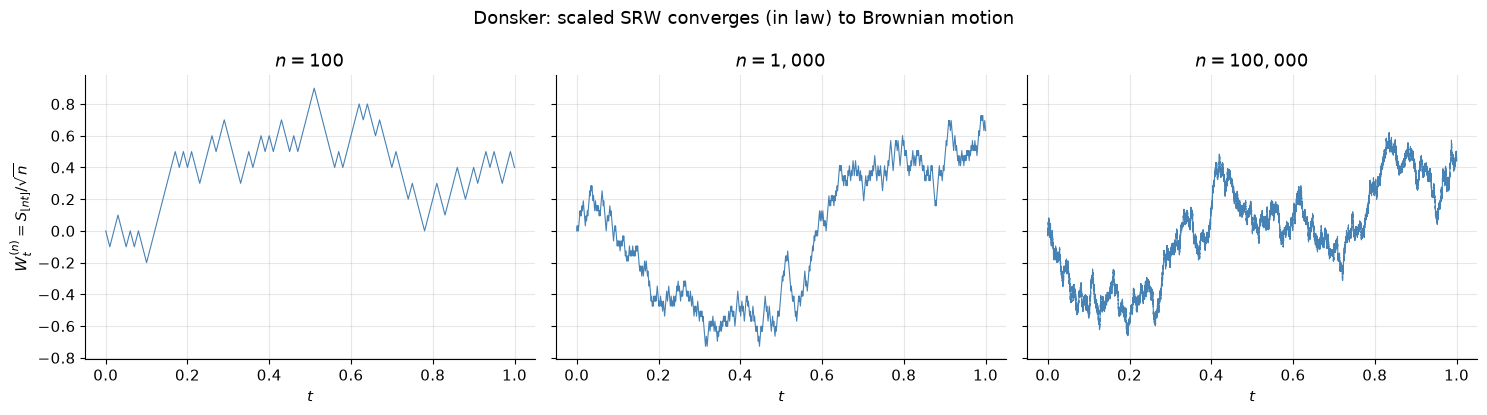

In [2]:
# Demo 1: scaled SRW -> BM, n in {10^2, 10^3, 10^5}
n_values = [100, 1_000, 100_000]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, n in zip(axes, n_values):
    steps = rng.choice([-1, 1], size=n)
    S = np.concatenate([[0], np.cumsum(steps)])
    t_grid = np.arange(n + 1) / n
    W_scaled = S / np.sqrt(n)

    ax.plot(t_grid, W_scaled, color="steelblue", linewidth=0.8)
    ax.set_xlabel("$t$")
    ax.set_title(f"$n={n:,}$")

axes[0].set_ylabel(r"$W_t^{(n)} = S_{\lfloor nt \rfloor}/\sqrt{n}$")
fig.suptitle(r"Donsker: scaled SRW converges (in law) to Brownian motion")
fig.tight_layout()
plt.show()

Con $n=10^2$ la trayectoria es visiblemente una escalera (los saltos individuales de tamaño $1/\sqrt{n}=0.1$ son perceptibles); con $n=10^3$ los saltos ya son pequeños ($\approx0.032$) y la trayectoria empieza a verse "rugosa" pero continua; con $n=10^5$ los saltos son de $\approx0.003$ y la trayectoria es indistinguible a simple vista de un BM simulado directamente (demo 3) — la convergencia de Donsker en acción. Nótese que cada panel usa una realización *distinta* (el rng avanza entre llamadas), así que no es la misma trayectoria "afinándose"; lo que comparamos es la distribución límite, no una trayectoria individual.

### Demo 2 — Variación cuadrática vs variación total sobre particiones refinadas

Simulamos una única trayectoria de BM muy fina (resolución $N_{\text{fine}}=2^{18}$ en $[0,T=1]$) y la sub-muestreamos en particiones $\Pi_k$ con $n_k=2^k$ puntos, $k=1,\dots,16$. Para cada partición calculamos $Q_{n_k}=\sum(\Delta W)^2$ (variación cuadrática) y $V_{n_k}=\sum|\Delta W|$ (variación total), y graficamos ambas contra $n_k$ en escala log-log: la sección 2.3 predice $Q_{n_k}\to T$ (converge, plano) mientras $\mathbb{E}[V_{n_k}]=\sqrt{2n_kT/\pi}$ (diverge como $\sqrt{n_k}$).

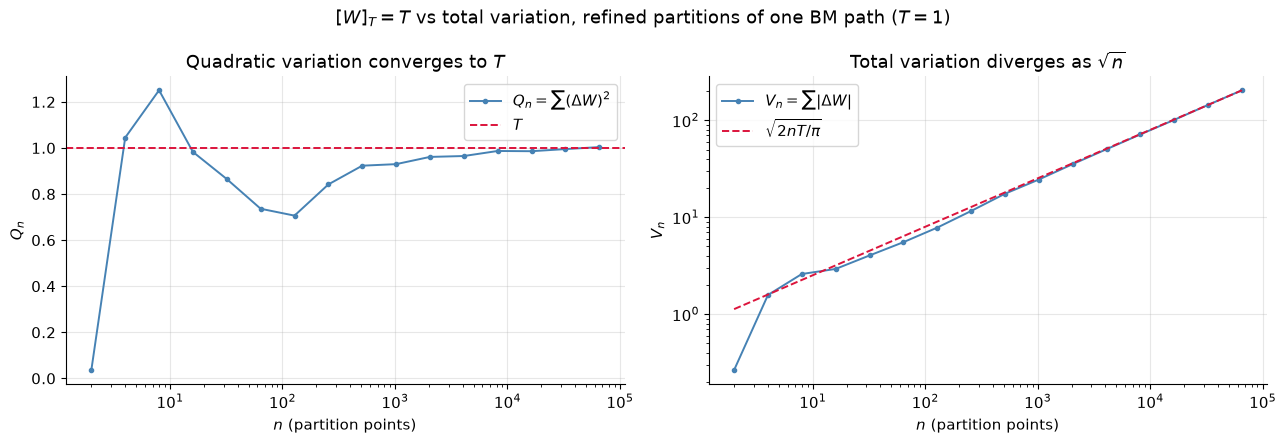

Q_n at finest partition (n=65,536): 1.00362  (T=1.0)
V_n at finest partition (n=65,536): 204.617  (theory sqrt(2nT/pi)=204.258)


In [3]:
# Demo 2: quadratic variation -> T, total variation diverges, over refined partitions of a single BM path
T = 1.0
N_fine = 2**18  # finest resolution: 262,144 steps
dt_fine = T / N_fine

increments_fine = rng.standard_normal(N_fine) * np.sqrt(dt_fine)
W_fine = np.concatenate([[0.0], np.cumsum(increments_fine)])

k_values = np.arange(1, 17)  # n_k = 2^1 ... 2^16
n_values_qv = 2**k_values
qv_values = np.empty_like(n_values_qv, dtype=float)
tv_values = np.empty_like(n_values_qv, dtype=float)

for idx, n_k in enumerate(n_values_qv):
    stride = N_fine // n_k
    W_sub = W_fine[::stride]
    dW_sub = np.diff(W_sub)
    qv_values[idx] = np.sum(dW_sub**2)
    tv_values[idx] = np.sum(np.abs(dW_sub))

tv_theory = np.sqrt(2 * n_values_qv * T / np.pi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].semilogx(n_values_qv, qv_values, marker="o", markersize=3, color="steelblue", label=r"$Q_n=\sum(\Delta W)^2$")
axes[0].axhline(T, color="crimson", linestyle="--", linewidth=1.4, label="$T$")
axes[0].set_xlabel("$n$ (partition points)")
axes[0].set_ylabel(r"$Q_n$")
axes[0].set_title("Quadratic variation converges to $T$")
axes[0].legend()

axes[1].loglog(n_values_qv, tv_values, marker="o", markersize=3, color="steelblue", label=r"$V_n=\sum|\Delta W|$")
axes[1].loglog(n_values_qv, tv_theory, color="crimson", linestyle="--", linewidth=1.4, label=r"$\sqrt{2nT/\pi}$")
axes[1].set_xlabel("$n$ (partition points)")
axes[1].set_ylabel(r"$V_n$")
axes[1].set_title("Total variation diverges as $\\sqrt{n}$")
axes[1].legend()

fig.suptitle(r"$[W]_T=T$ vs total variation, refined partitions of one BM path ($T=1$)")
fig.tight_layout()
plt.show()

print(f"Q_n at finest partition (n={n_values_qv[-1]:,}): {qv_values[-1]:.5f}  (T={T})")
print(f"V_n at finest partition (n={n_values_qv[-1]:,}): {tv_values[-1]:.3f}  (theory sqrt(2nT/pi)={tv_theory[-1]:.3f})")

El panel izquierdo muestra $Q_n$ oscilando cada vez más cerca de $T=1$ conforme la partición se refina — consistente con la convergencia en $L^2$ probada en 2.3 (aquí vemos una sola trayectoria, así que hay ruido, pero la tendencia es plana). El panel derecho, en escala log-log, muestra $V_n$ creciendo como una línea recta de pendiente $1/2$ — exactamente la tasa $\sqrt{n}$ predicha por $\mathbb{E}[V_n]=\sqrt{2nT/\pi}$ — y la trayectoria simulada sigue esa curva de cerca. Esta es la manifestación numérica directa del contraste que motiva el cálculo de Itô: mientras más fina la partición, la variación cuadrática se estabiliza pero la variación total explota.

### Demo 3 — Simulación exacta de trayectorias (incrementos gaussianos)

A diferencia de la SRW reescalada (demo 1), podemos simular BM **exactamente** en cualquier malla de tiempo: los incrementos $W_{t_{i+1}}-W_{t_i}$ son, por la Definición 1.1, gaussianos independientes de varianza $t_{i+1}-t_i$ — no hace falta ningún límite. Simulamos $n_{\text{paths}}=20$ trayectorias en $[0,T=1]$ con $n_{\text{steps}}=250$ pasos y las graficamos con `plot_paths`.

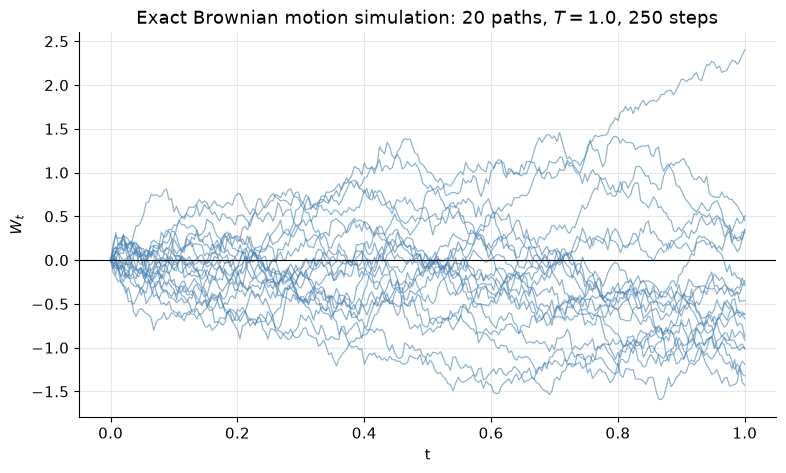

In [4]:
# Demo 3: exact BM path simulation via Gaussian increments, plotted with plot_paths
T_demo3 = 1.0
n_steps_demo3 = 250
n_paths_demo3 = 20
dt_demo3 = T_demo3 / n_steps_demo3

increments = rng.standard_normal((n_paths_demo3, n_steps_demo3)) * np.sqrt(dt_demo3)
W_paths = np.concatenate([np.zeros((n_paths_demo3, 1)), np.cumsum(increments, axis=1)], axis=1)
t_grid_demo3 = np.linspace(0, T_demo3, n_steps_demo3 + 1)

ax = plot_paths(t_grid_demo3, W_paths, color="steelblue", linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("$W_t$")
ax.set_title(f"Exact Brownian motion simulation: {n_paths_demo3} paths, $T={T_demo3}$, {n_steps_demo3} steps")
plt.show()

Las $20$ trayectorias parten todas de $W_0=0$ y se abren en abanico conforme $t$ crece — la dispersión creciente es $\sqrt{t}$, la desviación estándar de $W_t\sim\mathcal{N}(0,t)$. A diferencia de la demo 1, aquí no hay error de discretización de ningún tipo: los incrementos son exactamente gaussianos con la varianza correcta en cada paso, así que esta es la forma estándar de simular BM (y la base de cualquier simulador de SDE por Euler-Maruyama, 01.4).

### Demo 4 — Puente browniano condicionado en $W_1=0$

Construimos el puente $B_t=W_t-t\,W_1$ a partir de las mismas trayectorias de BM exacto ($T=1$): cada trayectoria de BM se transforma restando la línea recta que va de $(0,0)$ a $(1,W_1)$. El resultado debe estar anclado en $B_0=B_1=0$ y tener varianza máxima en $t=1/2$ (§2.4).

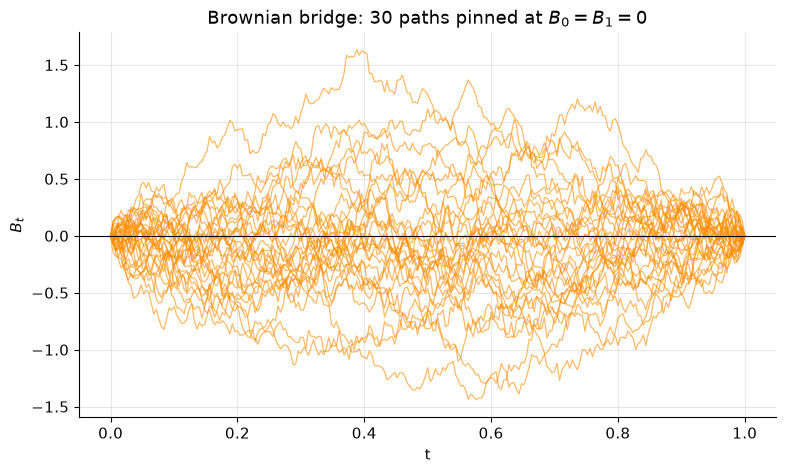

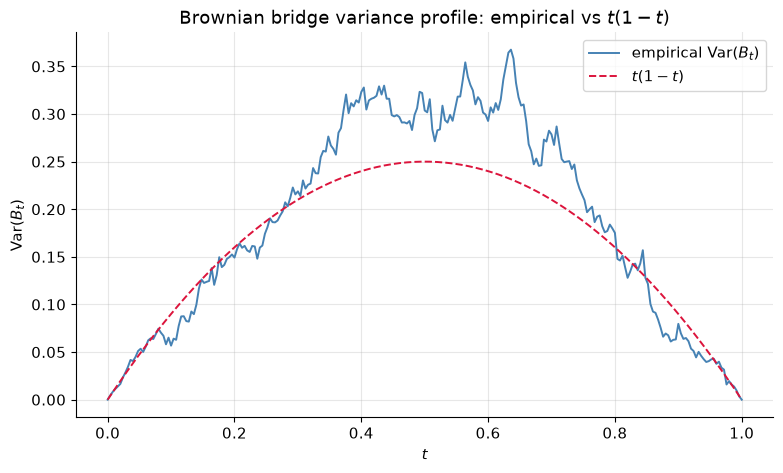

In [5]:
# Demo 4: Brownian bridge B_t = W_t - t*W_1, conditioned on W_1 = 0
n_steps_bridge = 250
n_paths_bridge = 30
dt_bridge = 1.0 / n_steps_bridge

increments_bridge = rng.standard_normal((n_paths_bridge, n_steps_bridge)) * np.sqrt(dt_bridge)
W_bridge_input = np.concatenate(
    [np.zeros((n_paths_bridge, 1)), np.cumsum(increments_bridge, axis=1)], axis=1
)
t_grid_bridge = np.linspace(0, 1, n_steps_bridge + 1)

W1 = W_bridge_input[:, -1]
B_paths = W_bridge_input - t_grid_bridge[None, :] * W1[:, None]

ax = plot_paths(t_grid_bridge, B_paths, color="darkorange", linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("$B_t$")
ax.set_title(f"Brownian bridge: {n_paths_bridge} paths pinned at $B_0=B_1=0$")
plt.show()

# Empirical variance profile vs theoretical t(1-t)
var_empirical = B_paths.var(axis=0)
var_theory = t_grid_bridge * (1 - t_grid_bridge)

fig, ax2 = plt.subplots()
ax2.plot(t_grid_bridge, var_empirical, color="steelblue", label="empirical Var($B_t$)")
ax2.plot(t_grid_bridge, var_theory, color="crimson", linestyle="--", label=r"$t(1-t)$")
ax2.set_xlabel("$t$")
ax2.set_ylabel(r"Var($B_t$)")
ax2.set_title("Brownian bridge variance profile: empirical vs $t(1-t)$")
ax2.legend()
plt.show()

Las trayectorias del puente (naranja) están todas ancladas en $0$ al inicio y al final por construcción, y la dispersión es visiblemente mayor en la mitad del intervalo — exactamente el perfil parabólico $t(1-t)$ derivado en §2.4, que la curva empírica (sobre solo $30$ trayectorias) sigue razonablemente bien. Este anclaje es lo que hace al puente browniano útil para simular condicionalmente (p.ej. "dado que el spot termina en un nivel específico, ¿cuál es la distribución de su máximo intermedio?", relevante para opciones barrera/lookback en 03.3-03.4).

## 4. Validación

Verificamos formalmente dos resultados derivados arriba, usando muestras grandes e independientes de las de las demos (mismo `rng`, sin reciclar arrays):

1. **Ley de $W_T$:** la media y varianza muestral de $W_T$ (simulado exactamente) deben caer dentro de $3$ errores estándar (SE) de $0$ y $T$ respectivamente.
2. **Variación cuadrática:** la media muestral de $Q_n=\sum(\Delta W)^2$ sobre muchas realizaciones independientes de una partición fija debe caer dentro de $3$ SE de $T$ (derivación §2.3: $\mathbb{E}[Q_n]=T$, $\text{Var}(Q_n)\leq 2T\|\Pi_n\|$).

In [6]:
# Validation 1: mean and variance of W_T within 3 SE of 0 and T
T_val = 1.0
n_val_wt = 100_000

W_T_samples = rng.standard_normal(n_val_wt) * np.sqrt(T_val)

mean_hat = W_T_samples.mean()
se_mean = W_T_samples.std(ddof=1) / np.sqrt(n_val_wt)

var_hat = W_T_samples.var(ddof=1)
se_var = np.sqrt(2.0 / (n_val_wt - 1)) * T_val  # Var(sample variance) ~= 2*sigma^4/(n-1), sigma^2=T

print(f"mean(W_T) = {mean_hat:.6f}, 3*SE = {3*se_mean:.6f}  (target 0)")
print(f"var(W_T)  = {var_hat:.6f}, 3*SE = {3*se_var:.6f}  (target T={T_val})")

assert abs(mean_hat - 0.0) <= 3 * se_mean, "mean(W_T) outside 3 SE of 0"
assert abs(var_hat - T_val) <= 3 * se_var, "var(W_T) outside 3 SE of T"

# Validation 2: mean quadratic variation over many independent partition realizations, within 3 SE of T
n_partition = 500
n_reps_qv = 50_000
dt_val = T_val / n_partition

qv_increments = rng.standard_normal((n_reps_qv, n_partition)) * np.sqrt(dt_val)
qv_samples = np.sum(qv_increments**2, axis=1)

qv_mean_hat = qv_samples.mean()
se_qv = qv_samples.std(ddof=1) / np.sqrt(n_reps_qv)

print(f"mean(Q_n) = {qv_mean_hat:.6f}, 3*SE = {3*se_qv:.6f}  (target T={T_val}, n={n_partition})")

assert abs(qv_mean_hat - T_val) <= 3 * se_qv, "mean quadratic variation outside 3 SE of T"

print("Validation passed: W_T mean/var within 3 SE of 0/T; mean quadratic variation within 3 SE of T.")

mean(W_T) = -0.000837, 3*SE = 0.009488  (target 0)
var(W_T)  = 1.000229, 3*SE = 0.013416  (target T=1.0)


mean(Q_n) = 0.999540, 3*SE = 0.000846  (target T=1.0, n=500)
Validation passed: W_T mean/var within 3 SE of 0/T; mean quadratic variation within 3 SE of T.


## Referencias

- Shreve, S. (2004). *Stochastic Calculus for Finance II: Continuous-Time Models*, cap. 3.
- Karatzas, I. & Shreve, S. (1991). *Brownian Motion and Stochastic Calculus*, 2nd ed. Springer, cap. 2.